[*********************100%***********************]  6 of 6 completed


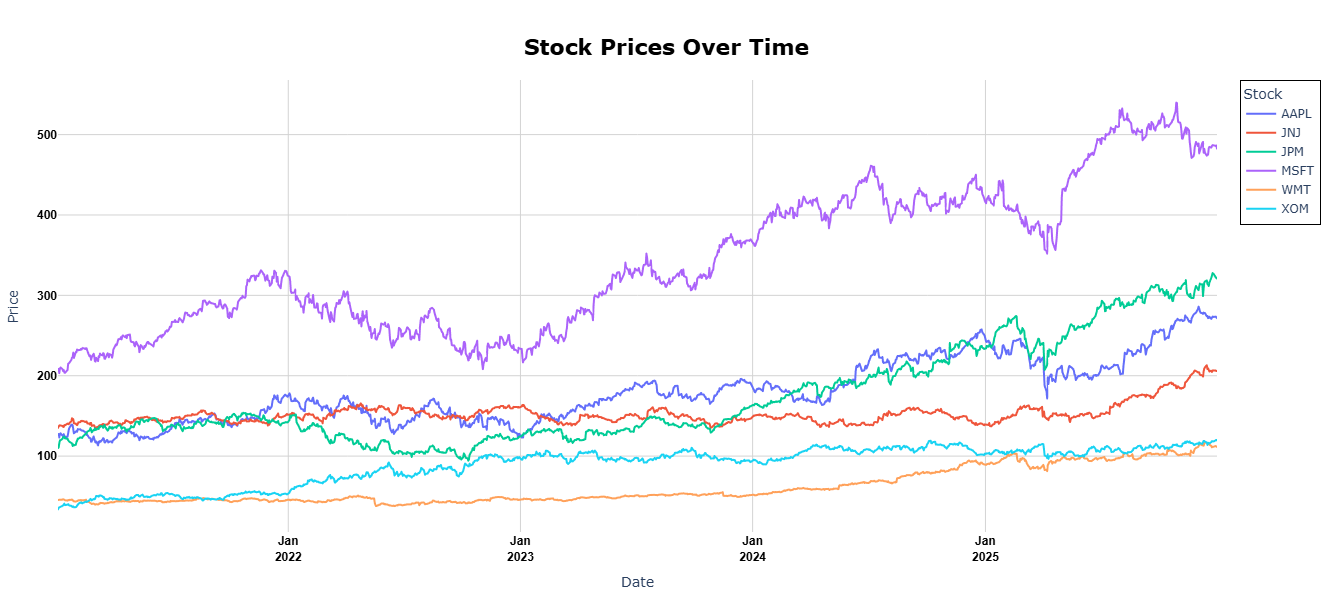

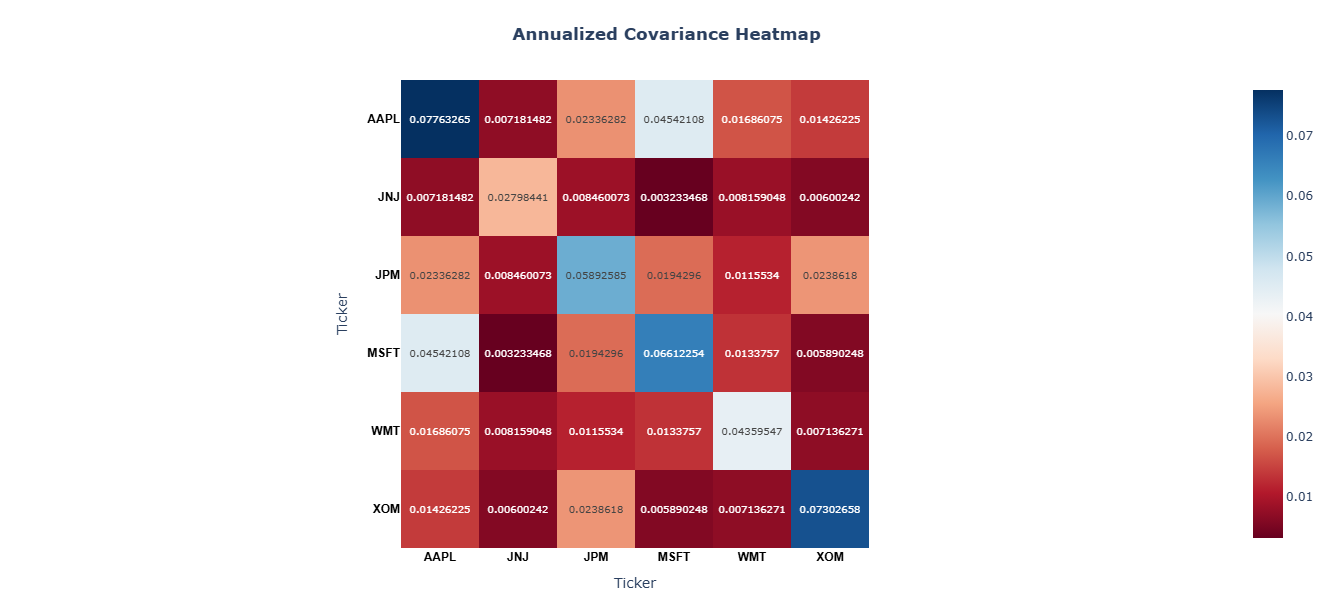

Max Sharpe Portfolio Weights: {'AAPL': np.float64(0.0), 'JNJ': np.float64(0.085), 'JPM': np.float64(0.17), 'MSFT': np.float64(0.157), 'WMT': np.float64(0.291), 'XOM': np.float64(0.297)}
Expected Return: 0.227
Volatility: 0.149
Sharpe Ratio: 1.384


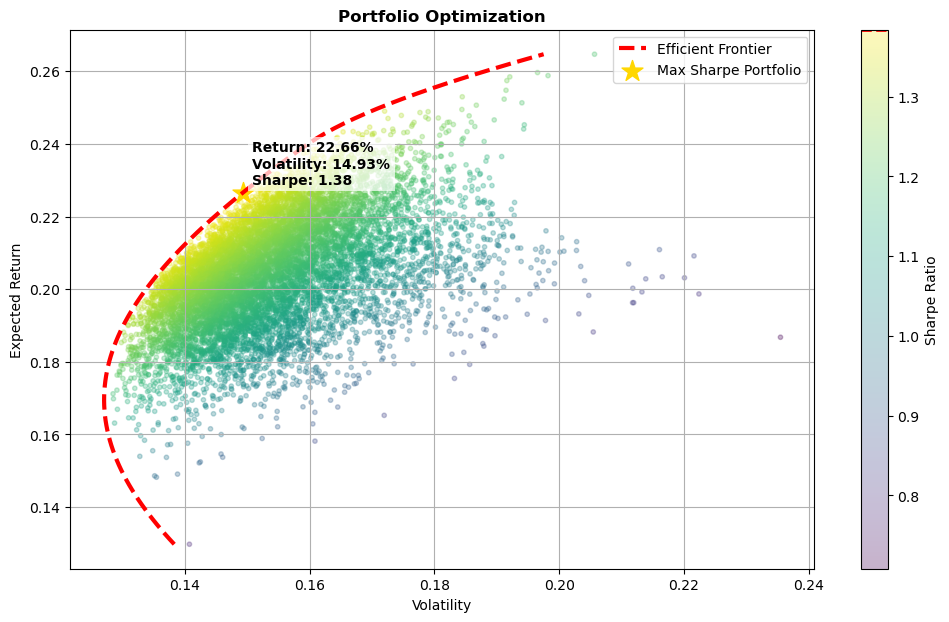

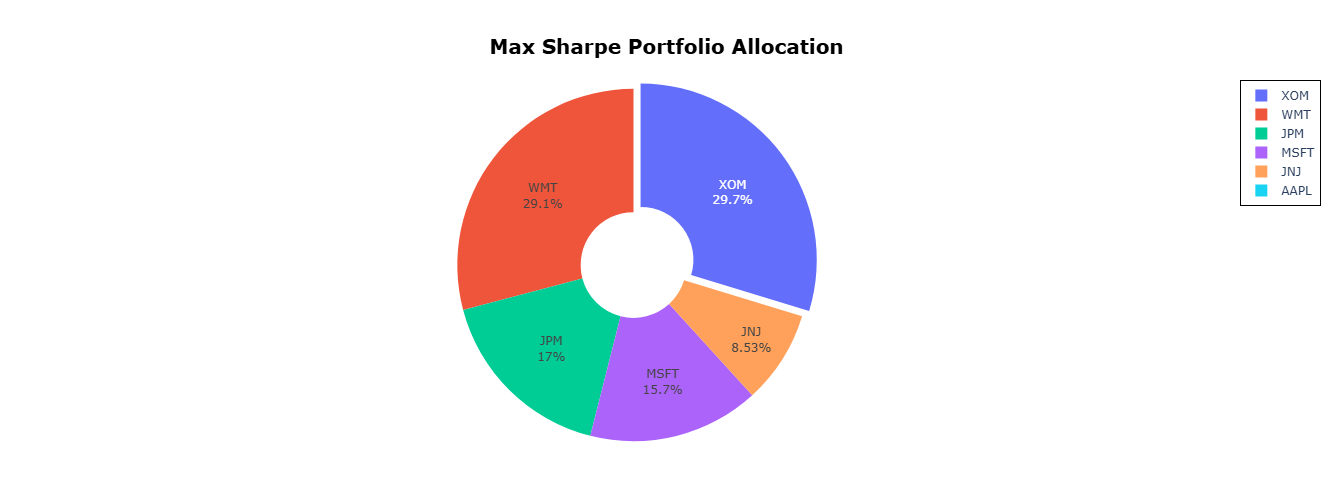

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import yfinance as yf
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Portfolio settings
stocks = ["AAPL", "MSFT", "XOM", "JPM", "JNJ", "WMT"]
stocks = list(dict.fromkeys(stocks))
start_date = '2021-01-01'
end_date = '2026-01-01'
trading_days = 252
num_portfolios = 10000
rf = 0.02  

# Download price data
data = yf.download(stocks, start=start_date, end=end_date)['Close']
data = data.dropna(axis=1, how='all')
stocks = data.columns.tolist()

# Simple returns
returns = data.pct_change().dropna()
annual_returns = returns.mean() * trading_days
annual_cov = returns.cov() * trading_days

# 1️⃣ Price chart (Plotly)
price_data = data.reset_index()
price_data_long = price_data.melt(id_vars='Date', value_vars=stocks,
                                  var_name='Stock', value_name='Price')

fig_prices = px.line(price_data_long, x='Date', y='Price', color='Stock')
fig_prices.update_layout(
    title=dict(
        text='<b>Stock Prices Over Time</b>',
        x=0.5,
        xanchor='center',
        yanchor='top',
        font=dict(color='black', size=22)
    ),
    width=1200,
    height=600,
    margin=dict(l=50, r=50, t=80, b=50),
    xaxis=dict(
        tickformat='%b\n%Y',
        dtick="M12",
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
        tickfont=dict(family='Arial', size=12, color='black', weight='bold')
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgray',
        gridwidth=1,
        tickfont=dict(family='Arial', size=12, color='black', weight='bold')
    ),
    legend=dict(
        bordercolor='black',
        borderwidth=1
    ),
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig_prices.show()

# 2️⃣ Covariance heatmap (Plotly)
fig_cov = px.imshow(
    annual_cov,
    text_auto=True,
    color_continuous_scale='RdBu',
    title='<b>Annualized Covariance Heatmap</b>'
)
fig_cov.update_layout(
    width=800,
    height=600,
    margin=dict(l=50, r=50, t=80, b=50),
    title=dict(x=0.5),
    xaxis=dict(tickfont=dict(family='Arial', size=12, color='black', weight='bold')),
    yaxis=dict(tickfont=dict(family='Arial', size=12, color='black', weight='bold'))
)
fig_cov.show()

# 3️⃣ Monte Carlo Simulation
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)
    weights_record.append(weights)

    port_return = np.dot(weights, annual_returns)
    port_vol = np.sqrt(weights.T @ annual_cov @ weights)
    sharpe = (port_return - rf) / port_vol

    results[0, i] = port_vol
    results[1, i] = port_return
    results[2, i] = sharpe

results_df = pd.DataFrame(results.T, columns=['Volatility', 'Return', 'Sharpe'])

# Portfolio performance function
def portfolio_performance(weights):
    port_return = np.dot(weights, annual_returns)
    port_vol = np.sqrt(weights.T @ annual_cov @ weights)
    sharpe = (port_return - rf) / port_vol
    return port_return, port_vol, sharpe

# Max Sharpe optimization
def neg_sharpe(weights):
    return -portfolio_performance(weights)[2]

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0,1) for _ in range(len(stocks)))
init_guess = np.array([1/len(stocks)]*len(stocks))

opt_result = minimize(neg_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
opt_weights = opt_result.x
opt_return, opt_vol, opt_sharpe = portfolio_performance(opt_weights)

print("Max Sharpe Portfolio Weights:", dict(zip(stocks, np.round(opt_weights,3))))
print("Expected Return:", round(opt_return,3))
print("Volatility:", round(opt_vol,3))
print("Sharpe Ratio:", round(opt_sharpe,3))

# Efficient frontier
target_returns = np.linspace(results_df['Return'].min(), results_df['Return'].max(), 100)
frontier_vols = []

for r in target_returns:
    cons = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, r=r: np.dot(w, annual_returns) - r}
    )
    result = minimize(lambda w: np.sqrt(w.T @ annual_cov @ w), init_guess,
                      method='SLSQP', bounds=bounds, constraints=cons)
    if result.success:
        frontier_vols.append(result.fun)
    else:
        frontier_vols.append(np.nan)

# 4️⃣ Optimization chart (Matplotlib)
plt.figure(figsize=(12,7))

scatter = plt.scatter(
    results_df['Volatility'], results_df['Return'],
    c=results_df['Sharpe'], cmap='viridis', s=10, alpha=0.3,
    vmin=results_df['Sharpe'].min(),
    vmax=max(results_df['Sharpe'].max(), opt_sharpe)
)
plt.plot(frontier_vols, target_returns, 'r--', linewidth=3, label='Efficient Frontier')
plt.scatter(opt_vol, opt_return, marker='*', color='gold', s=250, label='Max Sharpe Portfolio')

text_x = opt_vol * 1.01
text_y = opt_return * 1.01
plt.text(
    text_x, text_y,
    f"Return: {opt_return:.2%}\nVolatility: {opt_vol:.2%}\nSharpe: {opt_sharpe:.2f}",
    fontsize=10, fontweight='bold', color='black',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=3)
)

cbar = plt.colorbar(scatter, label='Sharpe Ratio')
cbar.ax.hlines(opt_sharpe, 0, 1, colors='red', linestyles='dashed', linewidth=2)

plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Portfolio Optimization', fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

# 5️⃣ Portfolio Allocation Pie Chart
weights_full = [opt_weights[i] if i < len(opt_weights) else 0 for i in range(len(stocks))]

fig_pie = px.pie(
    names=stocks,
    values=weights_full,
    title='<b>Max Sharpe Portfolio Allocation</b>',
    hole=0.3
)
fig_pie.update_traces(
    textposition='inside',
    textinfo='percent+label',
    pull=[0.05 if w == max(weights_full) else 0 for w in weights_full]
)
fig_pie.update_layout(
    width=700,
    height=500,
    margin=dict(l=50, r=50, t=80, b=50),
    title=dict(x=0.5, xanchor='center', yanchor='top', font=dict(color='black', size=20)),
    legend=dict(bordercolor='black', borderwidth=1),
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig_pie.show()